# Number Partitioning with QAOA — a `qcoptlib` demo

**Library demo · quantum-optimization repo**

A small, self-contained demonstration of the `qcoptlib` pipeline on a classic NP-hard problem:
**number partitioning** — split a set of values into two groups whose sums are as equal as
possible. The friendly framing is *fairly dividing an inheritance* between two siblings.

This notebook is thin by design: all the logic lives in `qcoptlib`. The notebook builds the
problem, solves it with QAOA, and checks the answer against brute force.

    values  ->  partition_qubo (qcoptlib.qubo)  ->  solve_qubo_qaoa (qcoptlib.quantum)  ->  decode + verify


## 1. The problem

Give each value a group (A or B). The **difference** between the two group sums is
`D = Σ vᵢ sᵢ` with `sᵢ = ±1`. We minimise `D²`, which expands into a sum of pairwise `ZᵢZⱼ`
terms weighted by `vᵢvⱼ` — a clean QUBO/Ising cost. `qcoptlib.qubo.partition_qubo` builds it.

The values below are chosen to split *perfectly* into two piles of \$57M each — a satisfying
ground truth to verify against.

In [1]:
from qcoptlib.qubo import partition_qubo, split_from_bits

# 13 property values (in $M). These happen to partition exactly.
values = [1, 5, 17, 1.5, 4.3, 13.8, 2, 2.3, 8.9, 21.9, 4.5, 7.1, 24.7]
print(f"{len(values)} values, total ${sum(values)}M, ideal half ${sum(values)/2}M")

qubo = partition_qubo(values)
print(f"QUBO: {qubo.n} binary variables (one per value)")


13 values, total $114.0M, ideal half $57.0M
QUBO: 13 binary variables (one per value)


## 2. Classical ground truth

Small enough (2¹³ splits) to brute-force the exact best split — the benchmark for QAOA.

In [2]:
best_bits, best_energy = qubo.brute_force()
group_a, group_b, gap = split_from_bits(best_bits, values)
print(f"Best split gap: ${gap:.2f}M")
print(f"  Group A (${sum(group_a):.1f}M): {sorted(group_a, reverse=True)}")
print(f"  Group B (${sum(group_b):.1f}M): {sorted(group_b, reverse=True)}")


Best split gap: $0.00M
  Group A ($57.0M): [17, 13.8, 7.1, 5, 4.5, 4.3, 2.3, 2, 1]
  Group B ($57.0M): [24.7, 21.9, 8.9, 1.5]


## 3. Solve with QAOA

`solve_qubo_qaoa` converts the QUBO to an Ising cost, builds the QAOA circuit, tunes the angles
(adiabatic-inspired init + a couple of restarts), and reads out the best sampled bitstring —
scored by the real objective, so a weakly-concentrated distribution still yields a good answer.
Runs on the Qiskit/Aer simulator (no account needed).

In [3]:
from qcoptlib.quantum.qiskit_backend import solve_qubo_qaoa

res = solve_qubo_qaoa(qubo, num_layers=3, maxiter=150, shots=8192, restarts=3, seed=0)

qa, qb, qgap = split_from_bits(res.best_bits, values)
print(f"QAOA split gap: ${qgap:.2f}M")
print(f"  Group A (${sum(qa):.1f}M): {sorted(qa, reverse=True)}")
print(f"  Group B (${sum(qb):.1f}M): {sorted(qb, reverse=True)}")
print()
print("Matches the optimum!" if qgap <= gap + 1e-6 else f"Gap ${qgap:.2f}M vs optimum ${gap:.2f}M")


QAOA split gap: $0.00M
  Group A ($57.0M): [24.7, 21.9, 7.1, 2.3, 1]
  Group B ($57.0M): [17, 13.8, 8.9, 5, 4.5, 4.3, 2, 1.5]

Matches the optimum!


## 4. Visualize the split

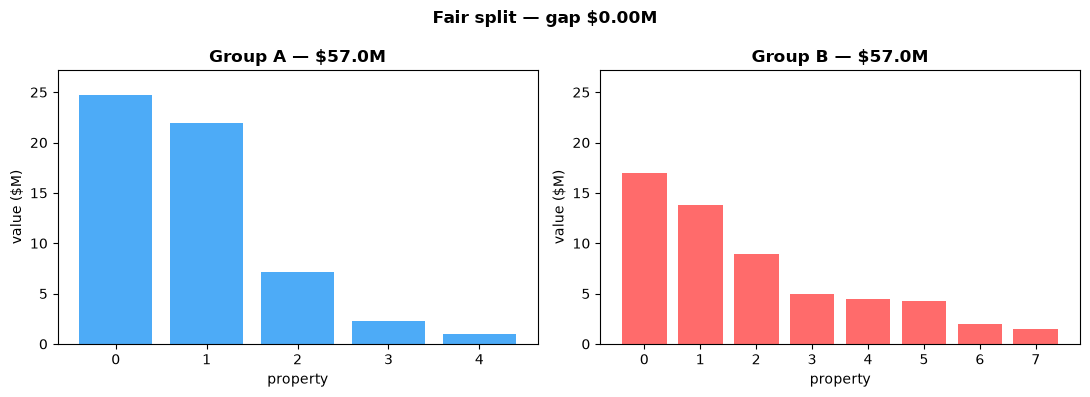

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, pile, title, color in [
    (ax[0], sorted(qa, reverse=True), f"Group A — ${sum(qa):.1f}M", "#4dabf7"),
    (ax[1], sorted(qb, reverse=True), f"Group B — ${sum(qb):.1f}M", "#ff6b6b"),
]:
    a.bar(range(len(pile)), pile, color=color)
    a.set_title(title, fontweight="bold")
    a.set_xlabel("property"); a.set_ylabel("value ($M)")
    a.set_ylim(0, max(values) * 1.1)
plt.suptitle(f"Fair split — gap ${qgap:.2f}M", fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Why this is a good demo

- **A real NP-hard problem** (number partitioning), not a toy — but small enough that QAOA
  solves it cleanly and we can verify against brute force.
- **The encoding is textbook-clean**: `D²` → pairwise `ZᵢZⱼ` terms, one call to `partition_qubo`.
- **Honest scaling note**: at 13 values brute force wins instantly; QAOA's interest is at scales
  where 2ⁿ splits become uncheckable. Demonstrating the full pipeline end-to-end, verified, is
  the point.

The same `qcoptlib` pipeline (`QUBO` → `solve_qubo_qaoa`) powers every problem in the portfolio —
this is just its smallest, clearest instance.
